In [1]:
import sys 
sys.path.append('..')
from csbm import *
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
color_list=['#2a557f','#46bd9c','#ef5076','#facd6e']
color_list_two=[(7/255,7/255,7/255),(255/255,59/255,59/255)]
matrix_list=['BS','GS','GN','BN']

In [ ]:
Ntest_results_mean=[]
Ntrain_results_mean=[]
Ntest_results_std=[]
Ntrain_results_std=[]
N_list=[80,100,200,500,800,1000,2000,5000]
for N in N_list:
    test_results=[[],[],[],[]]
    train_results=[[],[],[],[]]
    def P(A):
        return A
    for i in tqdm(range(100)):
        alpha=0.5
        gamma=1/alpha
        d=N**(1/2)/2
        lam=2
        mu=2
        r=0.01
        tau=0.8
        Alist=[]
        A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BS')
        Alist.append(A)
        for m in range(1,4):
            A,_,_=CSBM(N,alpha,d,lam,mu,matrix=matrix_list[m],genX=False)
            Alist.append(A)
        for m in range(4):
            _, _,  Etrain, Etest, _=LS(P(Alist[m]),X,y,r,tau=tau)
            test_results[m].append(Etest)
            train_results[m].append(Etrain)
    test_results=np.array(test_results)
    train_results=np.array(train_results)
    test_results_std=test_results.std(axis=1)
    test_results_mean=test_results.mean(axis=1)
    train_results_std=train_results.std(axis=1)
    train_results_mean=train_results.mean(axis=1)
    Ntest_results_mean.append(test_results_mean)
    Ntrain_results_mean.append(train_results_mean)
    Ntest_results_std.append(test_results_std)
    Ntrain_results_std.append(train_results_std)

100%|██████████| 100/100 [16:37<00:00,  9.98s/it]


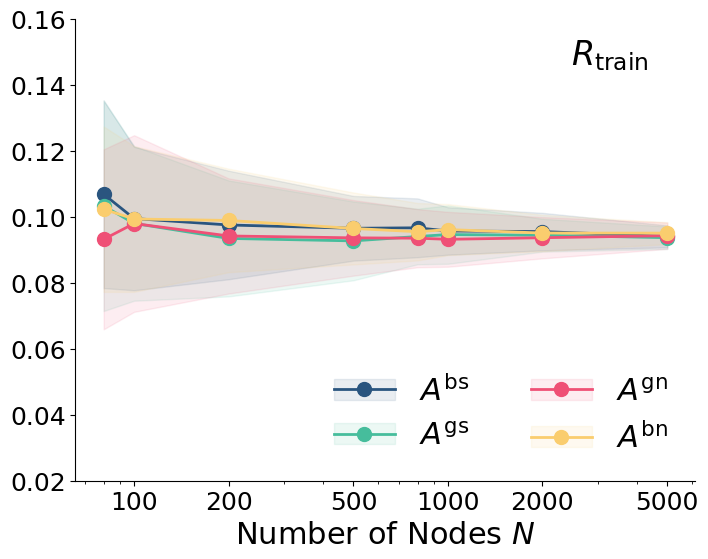

In [21]:
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
mean=Ntrain_results_mean
std=Ntrain_results_std
for m in range(4):
    ax.fill_between(N_list,mean[:,m]- std[:,m], mean[:,m] + std[:,m],color=color_list[m], alpha=0.1)
legend_list=[]
for m in range(4):
    p1=ax.plot(N_list,mean[:,m],'o-',color=color_list[m],linewidth=2,markersize=10)
    p2=ax.fill(np.NaN, np.NaN, color=color_list[m], alpha=0.1)
    legend_list.append((p2[0], p1[0]))

ax.text(0.8,0.9, r'$R_{\mathrm{train}}$', fontsize = 24,transform=ax.transAxes)

ax.legend(legend_list, [r'$A^{\mathrm{bs}}$',r'$A^{\mathrm{gs}}$',r'$A^{\mathrm{gn}}$',r'$A^{\mathrm{bn}}$'],frameon=False,ncol=2,fontsize=22,loc=4)
#ax.set_ylabel(r'$R_{\mathrm{train}}$',fontsize=22)
ax.set_xlabel(r'Number of Nodes $N$',fontsize=22)
ax.ticklabel_format(axis="y", style="sci")
ax.set_xscale('log')
ax.set_xticks([100,200,500,1000,2000,5000])
ax.set_xticklabels([100,200,500,1000,2000,5000])
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.set_ylim([0.02,0.16])

fig.savefig('f_N_train.pdf',bbox_inches='tight')

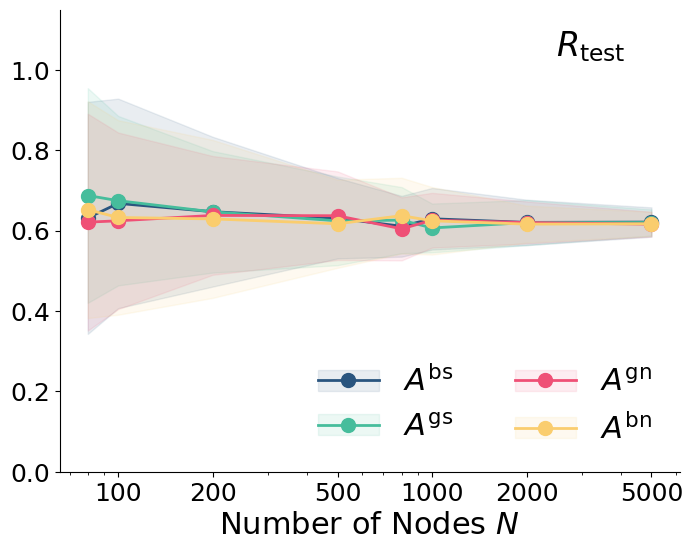

In [24]:
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
mean=Ntest_results_mean
std=Ntest_results_std
for m in range(4):
    ax.fill_between(N_list,mean[:,m]- std[:,m], mean[:,m] + std[:,m],color=color_list[m], alpha=0.1)
legend_list=[]
for m in range(4):
    p1=ax.plot(N_list,mean[:,m],'o-',color=color_list[m],linewidth=2,markersize=10)
    p2=ax.fill(np.NaN, np.NaN, color=color_list[m], alpha=0.1)
    legend_list.append((p2[0], p1[0]))


ax.text(0.8,0.9,r'$R_{\mathrm{test}}$', fontsize = 24,transform=ax.transAxes)
ax.legend(legend_list, [r'$A^{\mathrm{bs}}$',r'$A^{\mathrm{gs}}$',r'$A^{\mathrm{gn}}$',r'$A^{\mathrm{bn}}$'],frameon=False,ncol=2,fontsize=22,loc=4)
#ax.set_ylabel(r'$R_{\mathrm{test}}$',fontsize=22)
ax.set_xlabel(r'Number of Nodes $N$',fontsize=22)
ax.ticklabel_format(axis="y", style="sci")
ax.set_xscale('log')
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks([100,200,500,1000,2000,5000])
ax.set_xticklabels([100,200,500,1000,2000,5000])
ax.set_ylim([0.0,1.15])

fig.savefig('f_N_test.pdf',bbox_inches='tight')

In [14]:
from sklearn.linear_model import LinearRegression

In [ ]:
Ntest_results_mean=[]
Ntrain_results_mean=[]
Ntest_results_std=[]
Ntrain_results_std=[]
N_list=[80,100,200,500,800,1000,2000,5000]
repeat=100
for N in N_list:
    test_results=[[],[],[],[]]
    train_results=[[],[],[],[]]
    def P(A):
        return A
    for i in tqdm(range(repeat)):
        alpha=0.5
        gamma=1/alpha
        d=N**(1/2)/2
        lam=2
        mu=2
        r=0.01
        tau=0.8
        Alist=[]
        A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BS')
        Alist.append(A)
        for m in range(1,4):
            A,_,_=CSBM(N,alpha,d,lam,mu,matrix=matrix_list[m],genX=False)
            Alist.append(A)
        for m in range(4):
            _, _,  Etrain, Etest, _=LS(P(Alist[m]),X,y,r,tau=tau)
            test_results[m].append(Etest)
            train_results[m].append(Etrain)
    test_results=np.array(test_results)
    train_results=np.array(train_results)
    test_re=[]
    train_re=[]
    test_re.append(np.sum(np.abs(test_results[0]-test_results[0].mean()))/repeat)
    train_re.append(np.sum(np.abs(train_results[0]-train_results[0].mean()))/repeat)
    for m in range(1,4):
        test_re.append(np.sum(np.abs(test_results[m]-test_results[0]))/repeat)
        train_re.append(np.sum(np.abs(train_results[m]-train_results[0]))/repeat)

    Ntest_results_mean.append(np.array(test_re))
    Ntrain_results_mean.append(np.array(train_re))

100%|██████████| 100/100 [18:21<00:00, 11.02s/it]


0
1
2
3


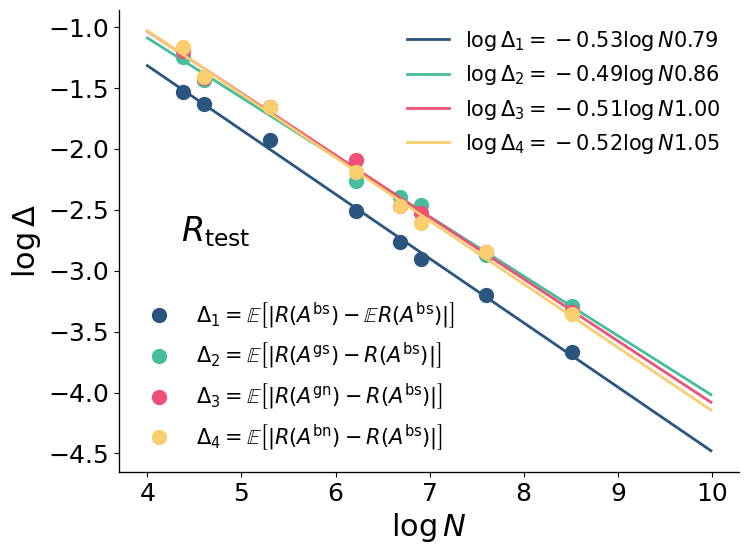

In [27]:
rM=np.array(Ntest_results_mean)
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax3 = ax.twinx()
legend_list=[]
for m in range(4):
    print(m)
    X=np.log(N_list).reshape(-1,1)
    Y=np.log(rM[:,m]).reshape(-1,1)
    Xnew=np.arange(4,10,0.01).reshape(-1,1)
    reg = LinearRegression().fit(X,Y)
    diabetes_y_pred = reg.predict(Xnew)
    ax.plot(X,Y,'o',color=color_list[m],markersize=10)
    ax.plot(Xnew,diabetes_y_pred,'-',color=color_list[m],linewidth=2)
    ax2.plot(np.NaN, np.NaN,'o',color=color_list[m],markersize=10)
    ax3.plot(np.NaN, np.NaN,'-',color=color_list[m],linewidth=2)

    legend_list.append(r'$\log \Delta_{:1}={:.2f}\log N{:.2f}$'.format(m+1,reg.coef_[0][0],reg.intercept_[0]))
    
ax2.get_yaxis().set_visible(False)
ax3.get_yaxis().set_visible(False)
ax2.legend([r'$\Delta_1=\mathbb{E}\left[\left|R(A^{\mathrm{bs}})-\mathbb{E}R(A^{\mathrm{bs}})\right|\right]$',r'$\Delta_2=\mathbb{E}\left[\left|R(A^{\mathrm{gs}})-R(A^{\mathrm{bs}})\right|\right]$',r'$\Delta_3=\mathbb{E}\left[\left|R(A^{\mathrm{gn}})-R(A^{\mathrm{bs}})\right|\right]$',r'$\Delta_4=\mathbb{E}\left[\left|R(A^{\mathrm{bn}})-R(A^{\mathrm{bs}})\right|\right]$'],frameon=False,loc=3,prop={'size': 15})


ax3.legend(legend_list,frameon=False,loc=1,prop={'size': 15})


ax.text(0.1,0.5, r'$R_{\mathrm{test}}$', fontsize = 24,transform=ax.transAxes)
ax.set_xlabel(r'$\log N$', fontsize = 22)
ax.set_ylabel(r'$\log \Delta$', fontsize = 22)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax2.spines.right.set_visible(False)
ax2.spines.top.set_visible(False)
ax2.yaxis.set_ticks_position('left')
ax2.xaxis.set_ticks_position('bottom')
ax3.spines.right.set_visible(False)
ax3.spines.top.set_visible(False)
ax3.yaxis.set_ticks_position('left')
ax3.xaxis.set_ticks_position('bottom')
fig.savefig('f_gg_test.pdf',bbox_inches='tight')

0
1
2
3


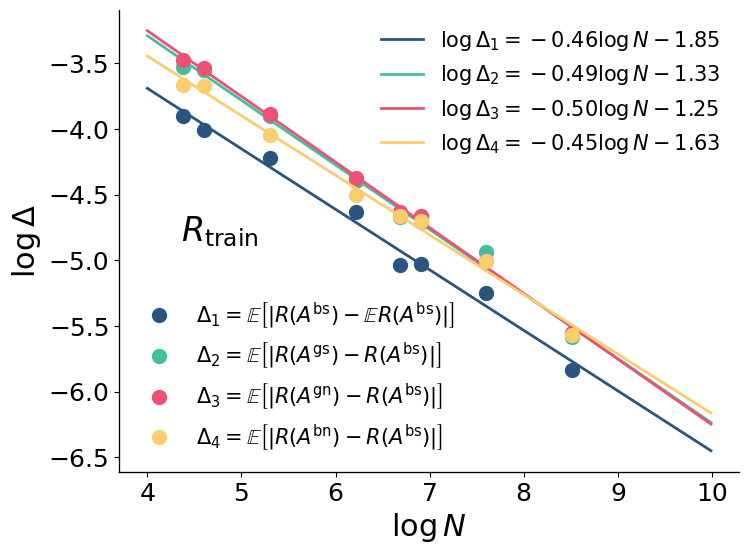

In [28]:
rM=np.array(Ntrain_results_mean)
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax3 = ax.twinx()
legend_list=[]
for m in range(4):
    print(m)
    X=np.log(N_list).reshape(-1,1)
    Y=np.log(rM[:,m]).reshape(-1,1)
    Xnew=np.arange(4,10,0.01).reshape(-1,1)
    reg = LinearRegression().fit(X,Y)
    diabetes_y_pred = reg.predict(Xnew)
    ax.plot(X,Y,'o',color=color_list[m],markersize=10)
    ax.plot(Xnew,diabetes_y_pred,'-',color=color_list[m],linewidth=2)
    ax2.plot(np.NaN, np.NaN,'o',color=color_list[m],markersize=10)
    ax3.plot(np.NaN, np.NaN,'-',color=color_list[m],linewidth=2)

    legend_list.append(r'$\log \Delta_{:1}={:.2f}\log N{:.2f}$'.format(m+1,reg.coef_[0][0],reg.intercept_[0]))
    
ax2.get_yaxis().set_visible(False)
ax3.get_yaxis().set_visible(False)
ax2.legend([r'$\Delta_1=\mathbb{E}\left[\left|R(A^{\mathrm{bs}})-\mathbb{E}R(A^{\mathrm{bs}})\right|\right]$',r'$\Delta_2=\mathbb{E}\left[\left|R(A^{\mathrm{gs}})-R(A^{\mathrm{bs}})\right|\right]$',r'$\Delta_3=\mathbb{E}\left[\left|R(A^{\mathrm{gn}})-R(A^{\mathrm{bs}})\right|\right]$',r'$\Delta_4=\mathbb{E}\left[\left|R(A^{\mathrm{bn}})-R(A^{\mathrm{bs}})\right|\right]$'],frameon=False,loc=3,prop={'size': 15})


ax3.legend(legend_list,frameon=False,loc=1,prop={'size': 15})



ax.text(0.1,0.5, r'$R_{\mathrm{train}}$', fontsize = 24,transform=ax.transAxes)
ax.set_xlabel(r'$\log N$', fontsize = 22)
ax.set_ylabel(r'$\log \Delta$', fontsize = 22)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax2.spines.right.set_visible(False)
ax2.spines.top.set_visible(False)
ax2.yaxis.set_ticks_position('left')
ax2.xaxis.set_ticks_position('bottom')
ax3.spines.right.set_visible(False)
ax3.spines.top.set_visible(False)
ax3.yaxis.set_ticks_position('left')
ax3.xaxis.set_ticks_position('bottom')
fig.savefig('f_gg_train.pdf',bbox_inches='tight')

In [5]:
Ntest_results_mean=[]
Ntrain_results_mean=[]
Ntest_results_std=[]
Ntrain_results_std=[]

def P(A):
    return A@A
d_list=np.arange(2,50,5)
d_list=d_list.tolist()
d_list.append(300)
d_list.append(500)
for d in d_list:
    N=2000
    test_results=[[],[],[],[]]
    train_results=[[],[],[],[]]
    for i in tqdm(range(100)):
        alpha=0.5
        gamma=1/alpha
        #d=np.sqrt(N)
        lam=1
        mu=1
        r=0.01
        tau=0.8
        Alist=[]
        A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BS')
        Alist.append(A)
        for m in range(1,4):
            A,_,_=CSBM(N,alpha,d,lam,mu,matrix=matrix_list[m],genX=False)
            Alist.append(A)
        for m in range(4):
            _, _,  Etrain, Etest, _=LS(P(Alist[m]),X,y,r,tau=tau)
            test_results[m].append(Etest)
            train_results[m].append(Etrain)

    test_results=np.array(test_results)
    train_results=np.array(train_results)
    test_results_std=test_results.std(axis=1)
    test_results_mean=test_results.mean(axis=1)
    train_results_std=train_results.std(axis=1)
    train_results_mean=train_results.mean(axis=1)
    Ntest_results_mean.append(test_results_mean)
    Ntrain_results_mean.append(train_results_mean)
    Ntest_results_std.append(test_results_std)
    Ntrain_results_std.append(train_results_std)


100%|██████████| 100/100 [03:20<00:00,  2.01s/it]


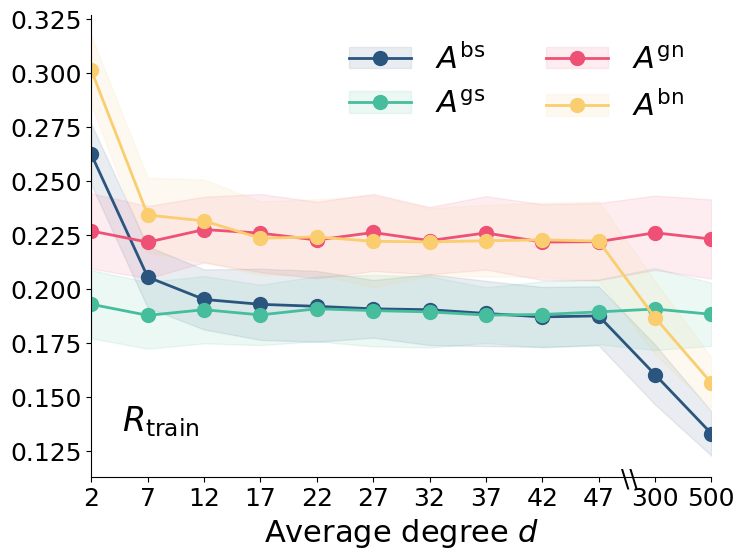

In [49]:
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
mean=Ntrain_results_mean
std=Ntrain_results_std
for m in range(4):
    ax.fill_between(range(len(d_list)),mean[:,m]- std[:,m], mean[:,m] + std[:,m],color=color_list[m], alpha=0.1)
legend_list=[]
for m in range(4):
    p1=ax.plot(range(len(d_list)),mean[:,m],'o-',color=color_list[m],linewidth=2,markersize=10)
    p2=ax.fill(np.NaN, np.NaN, color=color_list[m], alpha=0.1)
    legend_list.append((p2[0], p1[0]))

ax.text(0.05,0.1, r'$R_{\mathrm{train}}$', fontsize = 24,transform=ax.transAxes)

ax.legend(legend_list, [r'$A^{\mathrm{bs}}$',r'$A^{\mathrm{gs}}$',r'$A^{\mathrm{gn}}$',r'$A^{\mathrm{bn}}$'],frameon=False,ncol=2,fontsize=22)
ax.set_xticks(range(len(d_list)))
ax.set_xticklabels(d_list)
ax.set_xlabel('d')
ax.text(0.855,-0.02, '\\\\', fontsize = 18,transform=ax.transAxes)
#ax.text(0.855,0.98, '\\\\', fontsize = 18,transform=ax.transAxes)
ax.ticklabel_format(axis="y", style="sci")
ax.set_xlim([0,len(d_list)-1])
ax.set_xlabel(r'Average degree $d$',fontsize = 22)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
fig.savefig('f_d_train.pdf',bbox_inches='tight')

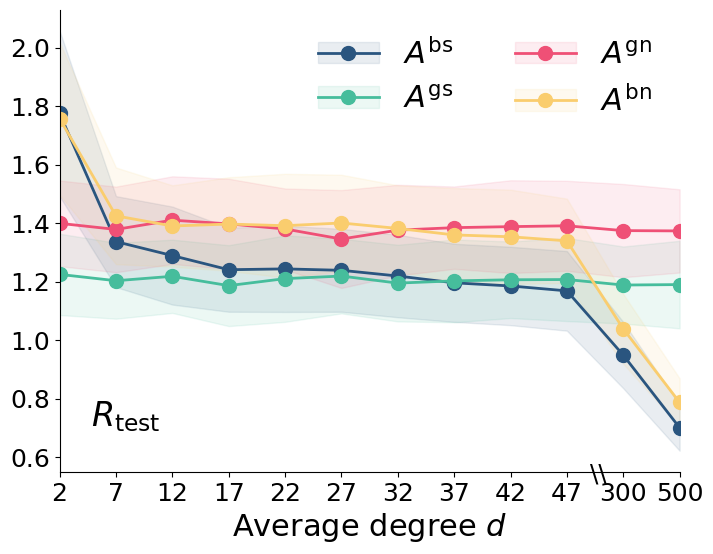

In [50]:
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
mean=Ntest_results_mean
std=Ntest_results_std
for m in range(4):
    ax.fill_between(range(len(d_list)),mean[:,m]- std[:,m], mean[:,m] + std[:,m],color=color_list[m], alpha=0.1)
legend_list=[]
for m in range(4):
    p1=ax.plot(range(len(d_list)),mean[:,m],'o-',color=color_list[m],linewidth=2,markersize=10)
    p2=ax.fill(np.NaN, np.NaN, color=color_list[m], alpha=0.1)
    legend_list.append((p2[0], p1[0]))

ax.text(0.05,0.1, r'$R_{\mathrm{test}}$', fontsize = 24,transform=ax.transAxes)
ax.legend(legend_list, [r'$A^{\mathrm{bs}}$',r'$A^{\mathrm{gs}}$',r'$A^{\mathrm{gn}}$',r'$A^{\mathrm{bn}}$'],frameon=False,ncol=2,fontsize=22)
ax.set_xticks(range(len(d_list)))
ax.set_xticklabels(d_list)
ax.set_xlabel(r'Average degree $d$',fontsize = 22)
ax.ticklabel_format(axis="y", style="sci")
ax.text(0.855,-0.02, '\\\\', fontsize = 18,transform=ax.transAxes)
#ax.text(0.855,0.98, '\\\\', fontsize = 18,transform=ax.transAxes)
ax.set_xlim([0,len(d_list)-1])
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
fig.savefig('f_d_test.pdf',bbox_inches='tight')